Libraries Imported Successfully!

Original Dataset:

   area  bedrooms  age  price
0   500         1   10     50
1   700         2    8     65
2   900         2    6     80
3  1100         3    5     95
4  1300         3    4    110
5  1500         4    3    130
6  1700         4    2    150
7  2000         5    1    180
8  2000         5    1    180

--- DATA CLEANING ---

After Cleaning:

   area  bedrooms  age  price
0   500         1   10     50
1   700         2    8     65
2   900         2    6     80
3  1100         3    5     95
4  1300         3    4    110
5  1500         4    3    130
6  1700         4    2    150
7  2000         5    1    180

--- HANDLING MISSING VALUES ---

Missing Values Before:

area        0
bedrooms    0
age         0
price       1
dtype: int64

Missing Values After:

area        0
bedrooms    0
age         0
price       0
dtype: int64

--- DATA FILTERING ---

Filtered Data (Area > 1000):

   area  bedrooms  age  price
3  1100         3    5   95.0
4

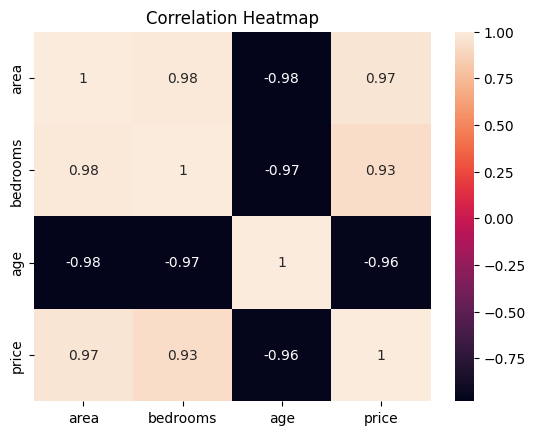

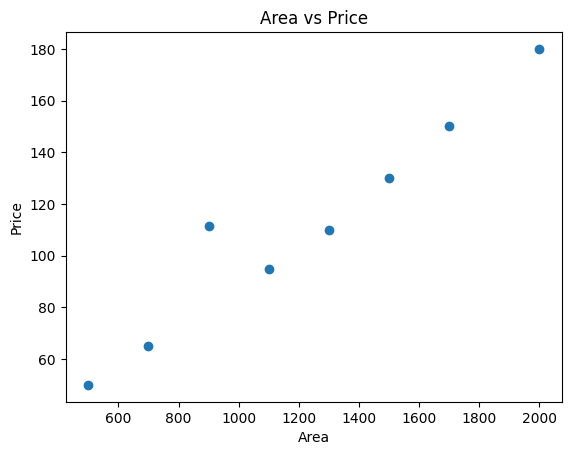

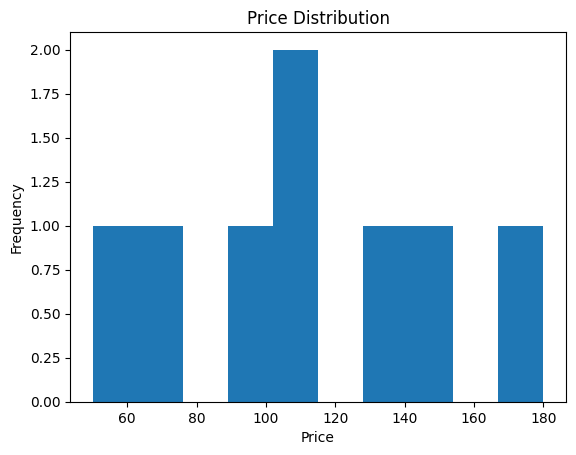


--- REGRESSION ANALYSIS ---

Model Coefficients: [  0.09793057 -19.25233645  -5.40720961]
Model Intercept: 76.64886515353791
R2 Score: 0.9987983229765468


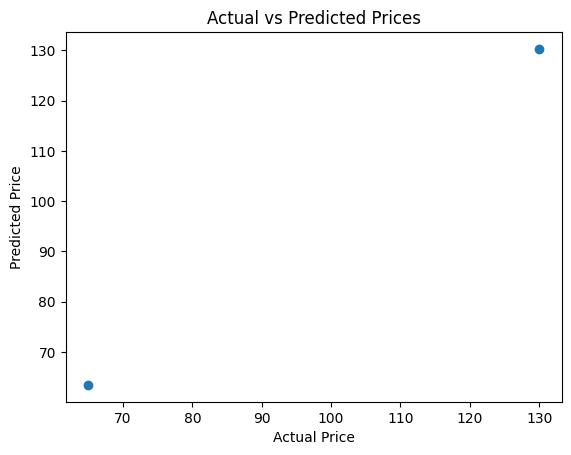


Project Completed Successfully!


In [2]:
# ================================
# HOUSE PRICE PREDICTION PROJECT
# ================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!\n")

# 2. CREATE DATASET
data = {
    'area': [500, 700, 900, 1100, 1300, 1500, 1700, 2000, 2000],
    'bedrooms': [1, 2, 2, 3, 3, 4, 4, 5, 5],
    'age': [10, 8, 6, 5, 4, 3, 2, 1, 1],
    'price': [50, 65, 80, 95, 110, 130, 150, 180, 180]
}

df = pd.DataFrame(data)

print("Original Dataset:\n")
print(df)

# 3. DATA CLEANING
print("\n--- DATA CLEANING ---")

# Remove duplicates
df = df.drop_duplicates()

# Standardize column names
df.columns = df.columns.str.lower()

print("\nAfter Cleaning:\n")
print(df)

# 4. HANDLE MISSING VALUES
print("\n--- HANDLING MISSING VALUES ---")

# Introduce NaN for demonstration
df.loc[2, 'price'] = np.nan

print("\nMissing Values Before:\n")
print(df.isnull().sum())

# Fill NaN with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nMissing Values After:\n")
print(df.isnull().sum())

# 5. DATA FILTERING
print("\n--- DATA FILTERING ---")

filtered_df = df[df['area'] > 1000]

print("\nFiltered Data (Area > 1000):\n")
print(filtered_df)

# 6. DATA VISUALIZATION

# Heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Scatter Plot
plt.figure()
plt.scatter(df['area'], df['price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

# Histogram
plt.figure()
plt.hist(df['price'])
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# 7. REGRESSION ANALYSIS
print("\n--- REGRESSION ANALYSIS ---")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Features and Target
X = df[['area', 'bedrooms', 'age']]
y = df['price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Results
print("\nModel Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))

# 8. REGRESSION VISUALIZATION
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

# 9. FINAL OUTPUT
print("\nProject Completed Successfully!")